In [1]:
# ======================================
# 📌 Hybrid PSO + Whale Optimization on Fixed CNN (Tomato Leaf Dataset)
# ======================================

# ✅ Libraries
import os
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# ✅ Dataset paths
base_dir = 'augmented_split_dataset'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# ✅ Parameters
IMG_SIZE = 256
BATCH_SIZE = 32

# ✅ Data generators
datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=True, seed=42
)

val_gen = datagen.flow_from_directory(
    val_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=False
)

test_gen = datagen.flow_from_directory(
    test_dir, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=False
)

# ✅ Number of classes
num_classes = train_gen.num_classes

# ======================================
# ✅ Fixed CNN Architecture (Baseline)
# ======================================
def build_base_cnn(dropout_rate=0.5, learning_rate=1e-4):
    model = models.Sequential([
        layers.Input(shape=(256, 256, 3)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer=Adam(learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# ======================================
# 🔁 Hybrid PSO + Whale Optimization
# ======================================

# 🔬 Fitness function: train CNN and return final validation accuracy
def evaluate_fitness(params):
    learning_rate = params[0]
    dropout_rate = params[1]

    model = build_base_cnn(dropout_rate=dropout_rate, learning_rate=learning_rate)

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=5,
        callbacks=[EarlyStopping(patience=2, monitor='val_loss')],
        verbose=0
    )

    val_acc = history.history['val_accuracy'][-1]
    return val_acc

# ✅ Bounds: [learning rate, dropout rate]
bounds = np.array([
    [1e-5, 1e-3],   # Learning Rate
    [0.3, 0.6]      # Dropout Rate
])

# ✅ Hybrid PSO + WOA
def hybrid_pso_woa(num_agents=5, max_iter=8):
    dim = bounds.shape[0]
    X = np.random.uniform(bounds[:, 0], bounds[:, 1], (num_agents, dim))
    V = np.zeros_like(X)
    fitness = np.array([evaluate_fitness(x) for x in X])

    p_best = X.copy()
    p_best_scores = fitness.copy()
    g_best = p_best[np.argmax(p_best_scores)]
    g_best_score = np.max(p_best_scores)

    a_decay = 2 / max_iter  # For WOA

    for t in range(max_iter):
        a = 2 - t * a_decay

        for i in range(num_agents):
            r = np.random.rand()
            A = 2 * a * r - a
            C = 2 * np.random.rand()
            l = np.random.uniform(-1, 1)
            p = np.random.rand()

            if t < max_iter // 2:
                # ✅ PSO phase
                inertia = 0.7
                cognitive = 1.5
                social = 1.5
                V[i] = (inertia * V[i] +
                        cognitive * random.random() * (p_best[i] - X[i]) +
                        social * random.random() * (g_best - X[i]))
                X[i] = X[i] + V[i]
            else:
                # ✅ Whale Optimization phase
                if p < 0.5:
                    if abs(A) < 1:
                        D = abs(C * g_best - X[i])
                        X[i] = g_best - A * D
                    else:
                        rand_idx = np.random.randint(num_agents)
                        D = abs(C * X[rand_idx] - X[i])
                        X[i] = X[rand_idx] - A * D
                else:
                    D = abs(g_best - X[i])
                    X[i] = D * np.exp(0.5 * l) * np.cos(2 * np.pi * l) + g_best

            # ✅ Clip to bounds
            X[i] = np.clip(X[i], bounds[:, 0], bounds[:, 1])

        # 🔄 Re-evaluate fitness
        fitness = np.array([evaluate_fitness(x) for x in X])
        for i in range(num_agents):
            if fitness[i] > p_best_scores[i]:
                p_best_scores[i] = fitness[i]
                p_best[i] = X[i]
            if fitness[i] > g_best_score:
                g_best_score = fitness[i]
                g_best = X[i]

        print(f"Generation {t+1}/{max_iter} | Best Validation Accuracy: {g_best_score:.4f}")

    return g_best, g_best_score

# ✅ Run Optimization
best_params, best_score = hybrid_pso_woa(num_agents=5, max_iter=8)
print("\n✅ Best Hyperparameters (PSO + WOA):")
print(f"Learning Rate: {best_params[0]:.6f}")
print(f"Dropout Rate : {best_params[1]:.2f}")
print(f"Best Validation Accuracy: {best_score:.4f}")


Found 21421 images belonging to 10 classes.
Found 4586 images belonging to 10 classes.
Found 4602 images belonging to 10 classes.


2025-06-23 09:09:16.736152: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Max
2025-06-23 09:09:16.736204: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2025-06-23 09:09:16.736214: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 10.67 GB
2025-06-23 09:09:16.736380: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-06-23 09:09:16.736399: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/simarkalsi/Projects/leafClassification/leaf/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class shoul

Generation 1/8 | Best Validation Accuracy: 0.8799
Generation 2/8 | Best Validation Accuracy: 0.8886
Generation 3/8 | Best Validation Accuracy: 0.8886
Generation 4/8 | Best Validation Accuracy: 0.8886
Generation 5/8 | Best Validation Accuracy: 0.8886
Generation 6/8 | Best Validation Accuracy: 0.8886
Generation 7/8 | Best Validation Accuracy: 0.8953
Generation 8/8 | Best Validation Accuracy: 0.8960

✅ Best Hyperparameters (PSO + WOA):
Learning Rate: 0.000267
Dropout Rate : 0.52
Best Validation Accuracy: 0.8960


In [2]:
# ✅ Final Training Using Best Hyperparameters
def build_final_cnn():
    model = models.Sequential([
        layers.Input(shape=(256, 256, 3)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(best_params[1]),  # optimized dropout
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=best_params[0]),  # optimized learning rate
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ✅ Callbacks
checkpoint = tf.keras.callbacks.ModelCheckpoint('hybrid_pso_woa_best_model.keras', monitor='val_accuracy', save_best_only=True)
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_schedule = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

# ✅ Train final model
model = build_final_cnn()
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=[checkpoint, early_stop, lr_schedule],
    verbose=1
)

# ✅ Test evaluation
test_loss, test_acc = model.evaluate(test_gen)
print(f"\n🧪 Test Accuracy: {test_acc:.4f}")


Epoch 1/25
670/670 ━━━━━━━━━━━━━━━━━━━━ 73s 102ms/step - accuracy: 0.4589 - loss: 1.5721 - val_accuracy: 0.6444 - val_loss: 1.0167 - learning_rate: 2.6725e-04
Epoch 2/25
670/670 ━━━━━━━━━━━━━━━━━━━━ 67s 100ms/step - accuracy: 0.7041 - loss: 0.8564 - val_accuracy: 0.7952 - val_loss: 0.5878 - learning_rate: 2.6725e-04
Epoch 3/25
670/670 ━━━━━━━━━━━━━━━━━━━━ 68s 101ms/step - accuracy: 0.7699 - loss: 0.6733 - val_accuracy: 0.8295 - val_loss: 0.4909 - learning_rate: 2.6725e-04
Epoch 4/25
670/670 ━━━━━━━━━━━━━━━━━━━━ 74s 110ms/step - accuracy: 0.8141 - loss: 0.5515 - val_accuracy: 0.8637 - val_loss: 0.3909 - learning_rate: 2.6725e-04
Epoch 5/25
670/670 ━━━━━━━━━━━━━━━━━━━━ 72s 107ms/step - accuracy: 0.8342 - loss: 0.4867 - val_accuracy: 0.7479 - val_loss: 0.7827 - learning_rate: 2.6725e-04
Epoch 6/25
670/670 ━━━━━━━━━━━━━━━━━━━━ 67s 100ms/step - accuracy: 0.8560 - loss: 0.4328 - val_accuracy: 0.8657 - val_loss: 0.4060 - learning_rate: 2.6725e-04
Epoch 7/25
670/670 ━━━━━━━━━━━━━━━━━━━━ 66s 99

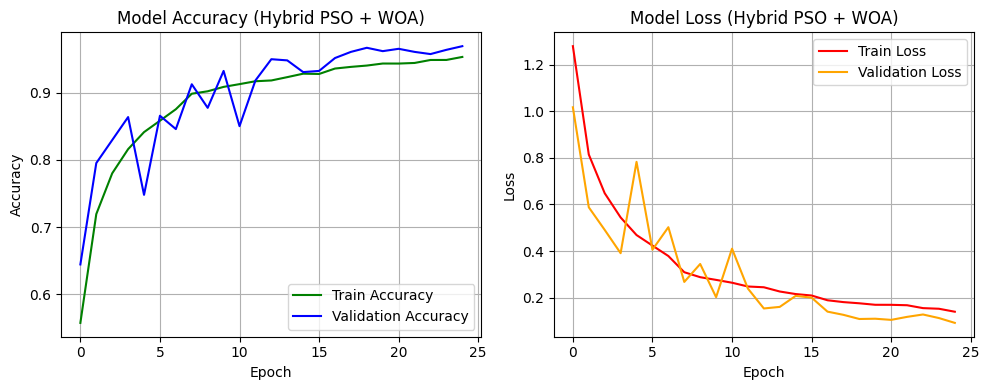

In [3]:
import matplotlib.pyplot as plt

# ✅ Accuracy Plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')
plt.title('Model Accuracy (Hybrid PSO + WOA)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# ✅ Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss (Hybrid PSO + WOA)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [4]:
# ✅ Evaluate saved best model on test set
from tensorflow.keras.models import load_model

best_model = load_model('hybrid_pso_woa_best_model.keras')
test_loss, test_accuracy = best_model.evaluate(test_gen, verbose=1)

print(f"\n🧪 Final Test Accuracy (Hybrid PSO + WOA): {test_accuracy:.4f}")

144/144 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9716 - loss: 0.0985

🧪 Final Test Accuracy (Hybrid PSO + WOA): 0.9752
